# The groundedness critic — cases

Every number in every triage brief must trace to a value the deterministic core
computed. The critic runs two passes (`src/critic.py`):

1. **deterministic** — pull the numerals out of the prose, match each against the
   dossier's computed values within tolerance. Reproducible; this is the backbone
   of the "100% of numeric claims traceable" target.
2. **LLM** — read the brief against the same values and flag overclaims, a
   direction that contradicts the forecast, or a missing caveat.

Briefs loop draft → review until clean or `CRITIC_MAX_ROUNDS`.


In [1]:
import os
if "src" not in os.listdir("."):
    os.chdir("..")

In [2]:
import pandas as pd
from src.store import load
from src.critic import review, check_numbers, CriticReport
w = load("watchlist")
print(len(w), "briefs on the watchlist across", w["asof"].nunique(), "sessions")
w[["asof","ticker","setup","groundedness","critic_rounds","critic_ok"]]

21 briefs on the watchlist across 3 sessions


,asof,ticker,setup,groundedness,critic_rounds,critic_ok
0,2025-05-28,TSLA,momentum-breakout,1,1,True
1,2025-05-28,HD,quiet,1,0,True
2,2025-05-28,DIS,trend-continuation,1,0,True
3,2025-05-28,MS,trend-continuation,1,2,True
4,2025-05-28,TXN,trend-continuation,1,1,True
5,2025-05-28,META,trend-continuation,1,2,True
6,2025-05-28,AAPL,range-bound,1,0,True
7,2025-06-16,ADBE,post-gap-drift,1,1,True
8,2025-06-16,CVX,trend-continuation,1,1,True
9,2025-06-16,JPM,momentum-breakout,1,0,True


## 1 · Groundedness across all briefs

mean groundedness at write time: 100.0%
briefs the critic passed clean:  21/21
briefs needing >=1 revision:      12


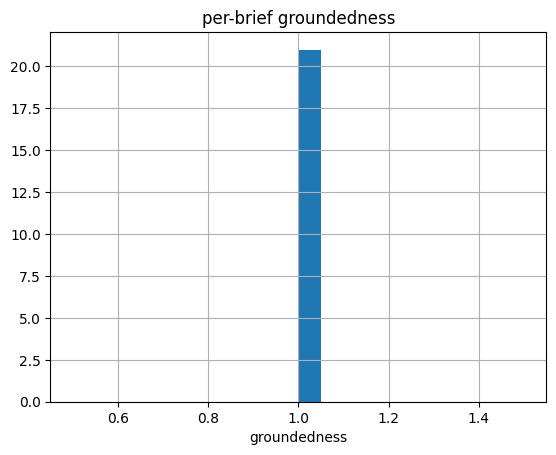

In [3]:
g = w["groundedness"].dropna()
print(f"mean groundedness at write time: {g.mean():.1%}")
print(f"briefs the critic passed clean:  {int(w['critic_ok'].fillna(False).sum())}/{len(w)}")
print(f"briefs needing >=1 revision:      {int((w['critic_rounds'].fillna(0) > 0).sum())}")
g.hist(bins=20); import matplotlib.pyplot as plt; plt.xlabel("groundedness"); plt.title("per-brief groundedness"); plt.show()

## 2 · The deterministic number-trace on one real brief

Every token the critic pulls, and whether it matched a computed value.

In [4]:
row = w.sort_values("groundedness").iloc[0]      # the weakest brief
print(f"{row['ticker']} — {row['asof']} — {row['setup']}\n")
print(row["brief_md"])

TSLA — 2025-05-28 — momentum-breakout

TSLA tops the flagged list on the back of a cross-sectional strength read of 2.26, with the model assigning 83% odds of a positive next-day move and a median expected return of 2.35%. The setup is a momentum-breakout: price sits essentially at the range high (range position 0.99, only 0.25% off the high), riding a well-established uptrend (trend r² of 0.78) after a 2.36% gap this morning, though short-term realized volatility is running below its longer-term average (ratio 0.58). Looking at the 11 prior instances of this same setup for TSLA, the base rate favored follow-through 64% of the time, with an average next-day return of +1.15% and typical absolute moves around 2.54% — a small but usable sample. The cluster read is cluster-aligned: mean absolute correlation across the 28-name peer set is 0.70, with a 71% same-sign frequency, indicating the move tends to travel with its correlated group rather than standing apart. There is no desk memory ye

In [5]:
# rebuild the value set the same way triage did
from src.features import rank_table
from src.forecasts import strength_history
from src.setups import setup_features
from src.data import load_context
f = load("forecasts"); asof, tk = str(row["asof"]), row["ticker"]
fr = f[(f["asof"].astype(str)==asof) & (f["ticker"]==tk)].iloc[0]
vals = {"q50":fr["q50"],"q05":fr["q05"],"q95":fr["q95"],"p_up":fr["p_up"],"std":fr["std"],"strength":fr["strength"]}
day = f[f["asof"].astype(str)==asof]
rt = rank_table(day[["ticker","q50","q05","q95","p_up","std","strength"]],
                strength_hist={t: strength_history(t, asof) for t in day["ticker"]})
vals["strength_z"] = float(rt[rt["ticker"]==tk].iloc[0]["strength_z"])
feats = setup_features(load_context(tk, asof).df, ticker=tk)
vals.update({k:v for k,v in feats.as_row().items() if isinstance(v,(int,float))})
if row["analog_base_rate"] is not None: vals["analog_base_rate"] = row["analog_base_rate"]
if row["analog_n"] is not None: vals["analog_n"] = row["analog_n"]

n, ok, bad = check_numbers(row["brief_md"], vals)
print(f"numbers found: {n}   grounded: {ok}   ungrounded: {len(bad)}")
for b in bad: print("  UNGROUNDED:", b)
pd.Series(vals).round(4)

/Users/isaac/Desktop/foundation_model_desk/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numbers found: 16   grounded: 16   ungrounded: 0


q50                   0.0235
q05                  -0.0101
q95                   0.0745
p_up                  0.8300
std                   0.0254
strength              0.9232
strength_z            2.2639
close               362.8900
trend_slope           0.0146
trend_r2              0.7774
dist_from_high       -0.0025
dist_from_low         0.4096
range_pos             0.9940
rvol_short            0.5112
rvol_long             0.8820
rvol_ratio            0.5795
last_gap              0.0236
gap_age               0.0000
stretch_from_ma       0.2999
analog_base_rate      0.6364
analog_n             11.0000
dtype: float64

## 3 · Planted failure — the critic must catch a wrong number

Take a clean brief, corrupt one figure, and confirm the critic flags it.

In [6]:
clean = w[w["critic_ok"].fillna(False)].iloc[0]
good_vals = {"q50":0.018,"p_up":0.82,"std":0.015,"strength":1.2,"analog_base_rate":0.63}
brief_ok = ("NVDA flagged on a momentum-breakout. Kronos median +1.8% with P(up) 82% "
            "and strength 1.2. Analogs: 63% up historically. "
            "Caveat: small analog sample, treat as descriptive.")
brief_bad = brief_ok.replace("+1.8%", "+7.4%").replace("82%", "97%")
for tag, b in [("clean", brief_ok), ("corrupted", brief_bad)]:
    r = review(b, good_vals, setup="momentum-breakout", require_caveat=True)
    print(f"[{tag}]  ok={r.ok}  groundedness={r.groundedness:.0%}  ungrounded={r.ungrounded}")

[clean]  ok=True  groundedness=100%  ungrounded=[]


[corrupted]  ok=False  groundedness=75%  ungrounded=['…ronos median +7.4% with P(up) 97% and strength 1…']


## 4 · The critic's feedback, verbatim

What gets sent back to the writer on a failed review.

In [7]:
r = review(brief_bad, good_vals, setup="momentum-breakout")
print(r.feedback())

- Numbers in the brief that match no computed value (remove or correct them): …ronos median +7.4% with P(up) 97% and strength 1…
- Median return stated as +7.4% but computed q50 is 1.8%
- P(up) stated as 97% but computed p_up is 82%


---
The deterministic pass is the guarantee: a number that matches no computed value
cannot survive to the PM, regardless of what the LLM writer or LLM critic think.